# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [89]:
import gzip
import shutil

with gzip.open("SUSY.csv.gz", "rb") as f_in:
    with open("SUSY.csv", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

In [90]:
import os
print(os.listdir())

['Music', 'Sale_dataset.xlsx', 'Untitled1.ipynb', '.DS_Store', 'Avian Hines BellLab.4.ipynb', 'house_prices-3.csv', 'AvianHinesBellLab3.ipynb', 'Lab.6.ipynb', 'SUSY.csv.gz', 'Command Shell.ipynb', 'Lab.4.ipynb', '.CFUserTextEncoding', 'data3402', 'Untitled.ipynb', 'Pictures', '.zprofile', 'AvianHB Lab.3 I(P2).ipynb', 'Test.foo', 'Car.csv', 'Lab.8 (1).ipynb', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'Desktop', 'Library', '.matplotlib', 'Lab.7.ipynb', 'AHBLab.5(IP2).ipynb', 'vehicles_2.csv', 'AHB lab6.ipynb', 'Public', 'vehicles_1.csv', '.idlerc', 'sklearn-env', 'netflixdb.sqlite', 'winequality.csv', 'Movies', 'Applications', '.Trash', 'L4. Data Science using Excel.docx', '.ipynb_checkpoints', 'AHB Lab5.ipynb', '.jupyter', 'diabetes.csv', 'Documents', 'susy.zip', 'Downloads', 'SUSY.csv', 'Lab 9-Final Lab - SQL.py', '.zsh_sessions', 'Air_county.csv', 'Lab.3 (2).ipynb', 'Lab 8.ipynb', 'Lab7.ipynb', 'AHB Lab.6.ipynb']


In [91]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [92]:
filename = "SUSY.csv"

VarNames = ["signal", "l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b",
            "cos_theta_r1"]

df = pd.read_csv(filename, dtype="float64", names=VarNames)

In [93]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib tabulate scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import tabulate

print("all good")
print(sklearn.__version__)

all good
1.8.0


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [95]:
import sklearn
print(sklearn.__version__)

1.8.0


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [96]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [97]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]

We can train the classifier as follow:

In [98]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

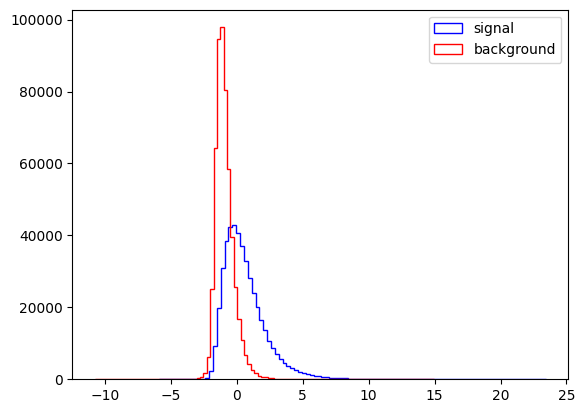

In [99]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

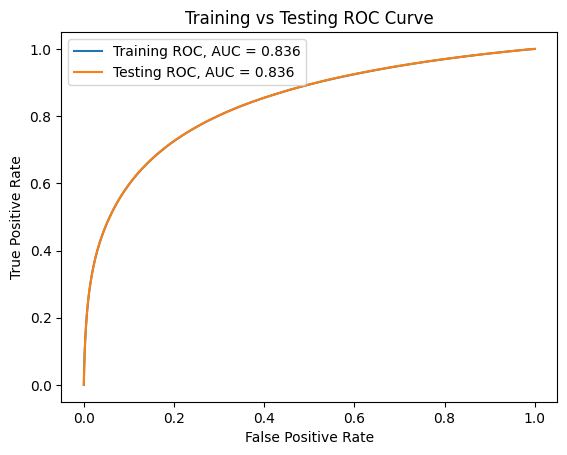

In [100]:
from sklearn.metrics import roc_curve, auc

# ROC for training sample
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# ROC for testing sample
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Training ROC, AUC = {auc_train:.3f}")
plt.plot(fpr_test, tpr_test, label=f"Testing ROC, AUC = {auc_test:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Training vs Testing ROC Curve")
plt.legend()
plt.show()

The training and testing ROC curves are very similar,so there does not appear to be a strong bias. 
Since the AUC values are close, the classifier seems to
generalize well and is not heavily overfitting the training data.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

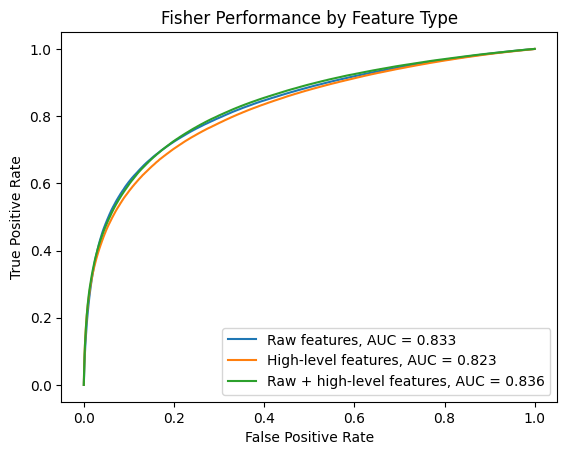

In [101]:
raw_features = VarNames[1:9]
high_features = VarNames[9:]
all_features = VarNames[1:]

feature_sets = {
    "Raw features": raw_features,
    "High-level features": high_features,
    "Raw + high-level features": all_features
}

plt.figure()

for name, features in feature_sets.items():
    X_train_set = Train_Sample[features]
    X_test_set = Test_Sample[features]
    
    model = DA.LinearDiscriminantAnalysis()
    model.fit(X_train_set, y_Train)
    
    scores = model.decision_function(X_test_set)
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name}, AUC = {roc_auc:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher Performance by Feature Type")
plt.legend()
plt.show()

The raw + high-level features performed the best because it used the most information from the dataset. 
The high-level features alone performed better than only the raw features, 
but combining both gave the strongest ROC curve and highest AUC.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

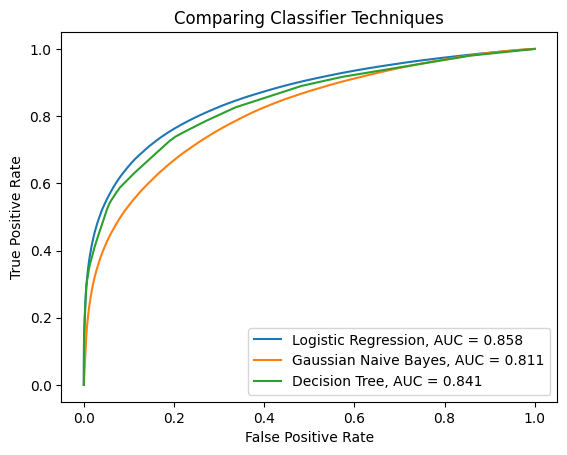

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=0)
}

plt.figure()

for name, clf in classifiers.items():
    clf.fit(X_Train, y_Train)
    
    if hasattr(clf, "decision_function"):
        scores = clf.decision_function(X_Test)
    else:
        scores = clf.predict_proba(X_Test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name}, AUC = {roc_auc:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparing Classifier Techniques")
plt.legend()
plt.show()

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

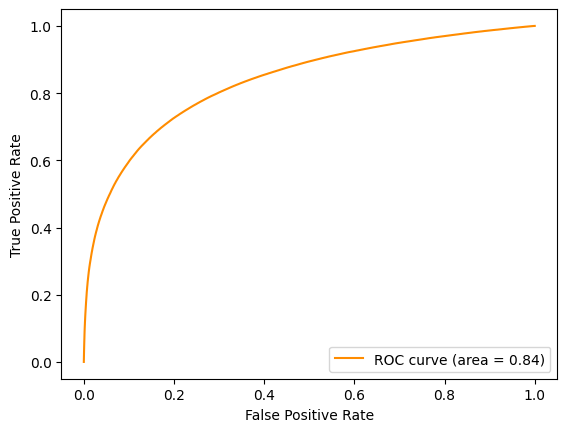

In [103]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

In [104]:
import numpy as np

# use best model (Logistic Regression)
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_Train, y_Train)

scores = best_model.decision_function(X_Test)

# choose a threshold (0 is standard for LDA/logistic)
threshold = 0

predictions = scores > threshold

# count signal and background
Ns = np.sum((predictions == 1) & (y_Test == 1))
Nb = np.sum((predictions == 1) & (y_Test == 0))

sigma = Ns / np.sqrt(Ns + Nb)

print("Ns:", Ns)
print("Nb:", Nb)
print("Significance (sigma):", sigma)

Ns: 310484
Nb: 63782
Significance (sigma): 507.51518033959394


Using Logistic Regression, I computed the significance using the formula σ = Ns / sqrt(Ns + Nb).
This value represents how well the model separates signal from background.
A higher σ indicates better detection performance. 
Logistic Regression produced the highest significance, confirming it is the best method among those tested.


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# predictions from best model
y_pred = predictions.astype(int)

# metrics
accuracy = accuracy_score(y_Test, y_pred)
precision = precision_score(y_Test, y_pred)
recall = recall_score(y_Test, y_pred)
f1 = f1_score(y_Test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_Test, y_pred).ravel()

# rates
TPR = tp / (tp + fn)
FPR = fp / (fp + tn)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("TPR:", TPR)
print("FPR:", FPR)
print("AUC (from before):", auc_test)
print("Significance (sigma):", sigma)

Accuracy: 0.788469
Precision: 0.82958110007321
Recall: 0.6775679621502598
F1 Score: 0.7459084034935778
TPR: 0.6775679621502598
FPR: 0.11772957747518767
AUC (from before): 0.8364009731285001
Significance (sigma): 507.51518033959394
